# PETalytics — Prediction Head Template (this instance: halo activity regressor)

**Three representations, one identical pipeline.** VAE latents (primary model), one-hot sequences
(baseline), and raw ESM-2 embeddings (the 'zero-shot ESM embeddings' comparison from the proposal --
also a baseline). All three run through the exact same CV-based Optuna search, resumable final
training with early stopping, and test evaluation code -- literally the same function, just called
with a different feature matrix each time. That's what makes the eventual comparison a fair one,
rather than three hand-written variants that could subtly differ in ways that bias the result.

**Reusable for another prediction head:** change the CONFIG cell (section 2). For classification
instead of regression, the SWAP POINTS are marked inside the pipeline function itself (section 8).

**Status: not run against live data.** Watch printed diagnostics at each step.

## 1. Setup

In [ ]:
!pip install -q optuna

import os
import json as jsonlib
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna
from transformers import AutoTokenizer, EsmModel
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 32.1 MB/s eta 0:00:00
Device: cuda
Mounted at /content/drive


## 2. CONFIG -- the main thing to change when reusing this notebook for a different head

In [ ]:
HEAD_NAME = 'halo_activity_regressor'

CSV_FILENAME = 'halo_BHET25_intensity.csv'
SEQUENCE_COLUMN = 'aa_sequence'
ID_COLUMN = 'gene_id'
TARGET_COLUMN = 'average_intensity'
TASK_TYPE = 'regression'   # 'regression' or 'classification' -- see SWAP POINTs in section 8

ESM_MODEL_NAME = 'facebook/esm2_t30_150M_UR50D'  # must match whatever generated the VAE's training data
MAX_SEQ_LEN = 1024

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

# Shared across all three runs (VAE latent / one-hot / raw ESM-2), so the comparison is apples-to-apples
N_TRIALS = 25
SEARCH_EPOCHS = 60
SEARCH_CV_FOLDS = 5
FINAL_EPOCHS = 300
PATIENCE = 20
CHECKPOINT_EVERY = 10
SEARCH_VERSION = 'v3'  # bump this whenever you change the search space/objective -- old trial
                        # history isn't valid for a different search space

EMB_DIR = '/content/drive/MyDrive/petalytics/embeddings'
VAE_DIR = '/content/drive/MyDrive/petalytics/vae'
HEAD_DIR = f'/content/drive/MyDrive/petalytics/heads/{HEAD_NAME}'
os.makedirs(HEAD_DIR, exist_ok=True)
print('Output directory for this head:', HEAD_DIR)

Output directory for this head: /content/drive/MyDrive/petalytics/heads/halo_activity_regressor


## 3. Find, load, and report on the best VAE

In [ ]:
VAE_CHECKPOINT_PATH = os.path.join(VAE_DIR, 'vae_best_val.pt')
assert os.path.exists(VAE_CHECKPOINT_PATH), f'No VAE checkpoint found at {VAE_CHECKPOINT_PATH}'

vae_ckpt = torch.load(VAE_CHECKPOINT_PATH, map_location=device)
vae_hp = vae_ckpt['hyperparams']

import datetime
mtime = os.path.getmtime(VAE_CHECKPOINT_PATH)
print('=== VAE being used ===')
print('Path:', VAE_CHECKPOINT_PATH)
print('Last modified:', datetime.datetime.fromtimestamp(mtime))
print('Hidden dims:', vae_hp['hidden_dims'])
print('Latent dim:', vae_hp['latent_dim'])
print('Saved at epoch:', vae_ckpt.get('epoch', 'n/a'))
print('Validation reconstruction loss at that epoch:', vae_ckpt.get('val_recon', 'n/a'))

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        encoder_layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            encoder_layers += [nn.Linear(prev_dim, h), nn.ReLU()]
            prev_dim = h
        self.encoder_backbone = nn.Sequential(*encoder_layers)
        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_logvar = nn.Linear(prev_dim, latent_dim)

    def encode(self, x):
        h = self.encoder_backbone(x)
        return self.fc_mu(h), self.fc_logvar(h)

emb_mean = np.load(os.path.join(EMB_DIR, 'vae_emb_mean.npy'))
emb_std = np.load(os.path.join(EMB_DIR, 'vae_emb_std.npy'))

vae = VAE(input_dim=emb_mean.shape[1], hidden_dims=vae_hp['hidden_dims'],
          latent_dim=vae_hp['latent_dim']).to(device)
vae.load_state_dict(vae_ckpt['model_state_dict'], strict=False)
vae.eval()
print()
print('VAE loaded and ready.')

=== VAE being used ===
Path: /content/drive/MyDrive/petalytics/vae/vae_best_val.pt
Last modified: 2026-07-16 08:51:27
Hidden dims: [256, 128]
Latent dim: 36
Saved at epoch: 93
Validation reconstruction loss at that epoch: 80.32096129964192

VAE loaded and ready.


## 4. Load the CSV, deduplicate, embed with ESM-2, encode through the VAE
Upload the CSV named in `CSV_FILENAME` above first.

In [ ]:
df = pd.read_csv(CSV_FILENAME)
print(f'Loaded {len(df)} rows.')

n_before = len(df)
dup_mask = df[SEQUENCE_COLUMN].duplicated(keep='first')
if dup_mask.sum() > 0:
    print(f'{dup_mask.sum()} exact duplicate sequences found, dropping.')
    df = df[~dup_mask].reset_index(drop=True)
print(f'{n_before} -> {len(df)} rows after deduplication.')

df = df.dropna(subset=[SEQUENCE_COLUMN, TARGET_COLUMN]).reset_index(drop=True)
print(f'{len(df)} rows remain after dropping missing sequence/target values.')

Loaded 257 rows.
3 exact duplicate sequences found, dropping.
257 -> 254 rows after deduplication.
254 rows remain after dropping missing sequence/target values.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(ESM_MODEL_NAME)
esm_model = EsmModel.from_pretrained(ESM_MODEL_NAME).to(device).eval()

sequences = df[SEQUENCE_COLUMN].tolist()
esm_embeddings = []
BATCH_SIZE_EMBED = 16
with torch.no_grad():
    for start in range(0, len(sequences), BATCH_SIZE_EMBED):
        batch_seqs = sequences[start:start + BATCH_SIZE_EMBED]
        inputs = tokenizer(batch_seqs, return_tensors='pt', padding=True, truncation=True,
                            max_length=MAX_SEQ_LEN).to(device)
        out = esm_model(**inputs)
        mask = inputs['attention_mask'].unsqueeze(-1).float()
        summed = (out.last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        esm_embeddings.append((summed / counts).cpu().numpy())
esm_embeddings = np.concatenate(esm_embeddings, axis=0)  # raw ESM-2, used directly as baseline 2

assert esm_embeddings.shape[1] == emb_mean.shape[1], (
    f'Dimension mismatch: ESM output is {esm_embeddings.shape[1]}-dim but the VAE expects '
    f'{emb_mean.shape[1]}-dim. Check ESM_MODEL_NAME matches whatever generated the VAE training data.'
)
assert not np.isnan(esm_embeddings).any()
print('Raw ESM-2 embeddings:', esm_embeddings.shape)

esm_standardized = (esm_embeddings - emb_mean) / emb_std
with torch.no_grad():
    mu, _ = vae.encode(torch.tensor(esm_standardized, dtype=torch.float32).to(device))
X_vae_latent = mu.cpu().numpy()  # primary model features
y = df[TARGET_COLUMN].values.astype(np.float32)
print('VAE latent features:', X_vae_latent.shape, ' Targets:', y.shape)

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Raw ESM-2 embeddings: (254, 640)
VAE latent features: (254, 36)  Targets: (254,)


## 5. One-hot sequence features (baseline 1)

In [ ]:
STANDARD_AA = set('ACDEFGHIKLMNPQRSTVWYX')
AA_VOCAB = list(STANDARD_AA) + ['<pad>']
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_VOCAB)}

seq_lengths = df[SEQUENCE_COLUMN].str.len()
ONEHOT_MAX_LEN = min(int(seq_lengths.quantile(0.95)), 800)
print('One-hot max length:', ONEHOT_MAX_LEN)

def one_hot_encode(seq, max_len=ONEHOT_MAX_LEN):
    seq = seq[:max_len]
    idxs = [AA_TO_IDX.get(aa, AA_TO_IDX['X']) for aa in seq]
    idxs += [AA_TO_IDX['<pad>']] * (max_len - len(idxs))
    one_hot = np.zeros((max_len, len(AA_VOCAB)), dtype=np.float32)
    one_hot[np.arange(max_len), idxs] = 1.0
    return one_hot.flatten()

X_onehot = np.stack(df[SEQUENCE_COLUMN].apply(one_hot_encode).values)
print('One-hot feature matrix:', X_onehot.shape)

One-hot max length: 461
One-hot feature matrix: (254, 10142)


## 6. Train / validation / test split -- shared across all three runs
Computed once, reused identically for the primary model and both baselines, so all three are
evaluated on the exact same held-out examples. **Small-sample caveat, worth stating in the report:**
with this few total examples, the test set is only ~15% of an already-small dataset.

In [ ]:
idx = np.arange(len(y))
train_idx, temp_idx = train_test_split(idx, test_size=(VAL_FRAC + TEST_FRAC), random_state=42)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC), random_state=42)
print(f'Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}')

Train: 177, Val: 38, Test: 39


## 7. The prediction head model and loss function

In [ ]:
class PredictionHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

loss_fn = nn.MSELoss()  # SWAP POINT (classification): nn.BCEWithLogitsLoss(pos_weight=...)

## 8. The shared pipeline: CV-based Optuna search -> resumable final training -> test evaluation
Called once per representation in section 9. Identical logic every time -- only `X_full` and
`run_name` change. Resumable at both the search level (SQLite database, backed up to Drive after
every trial) and the final-training level (checkpoint embeds its own hyperparameters, so a mismatch
is detected and handled gracefully rather than crashing).

**SWAP POINTs for classification** (three spots, marked inline below): the CV objective's per-fold
metric, the model's final-layer interpretation, and the test evaluation metrics.

In [ ]:
def run_pipeline(X_full, y_full, train_idx, val_idx, test_idx, run_name):
    print(f'\n{"="*70}\nPIPELINE: {run_name}  (input dim={X_full.shape[1]})\n{"="*70}')
    search_pool_idx = np.concatenate([train_idx, val_idx])  # test_idx never enters the search

    # ---- CV-based Optuna search ----
    def objective(trial):
        hidden_dim = trial.suggest_categorical('hidden_dim', [8, 16, 32])
        dropout = trial.suggest_float('dropout', 0.1, 0.6)
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)
        batch_size = trial.suggest_categorical('batch_size', [16, 32])

        kf = KFold(n_splits=SEARCH_CV_FOLDS, shuffle=True, random_state=42)
        fold_val_losses = []
        for cv_train_sub, cv_val_sub in kf.split(search_pool_idx):
            cv_train_idx = search_pool_idx[cv_train_sub]
            cv_val_idx = search_pool_idx[cv_val_sub]

            cv_scaler = StandardScaler().fit(X_full[cv_train_idx])
            X_cv_train = cv_scaler.transform(X_full[cv_train_idx])
            X_cv_val = cv_scaler.transform(X_full[cv_val_idx])

            cv_y_mean = y_full[cv_train_idx].mean()
            cv_y_std = y_full[cv_train_idx].std() + 1e-8
            y_cv_train = (y_full[cv_train_idx] - cv_y_mean) / cv_y_std
            y_cv_val = (y_full[cv_val_idx] - cv_y_mean) / cv_y_std  # SWAP POINT (classification):
            # use class labels directly here instead of standardizing a continuous target

            fold_model = PredictionHead(X_full.shape[1], hidden_dim, dropout).to(device)
            fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=learning_rate,
                                               weight_decay=weight_decay)

            X_cv_train_t = torch.tensor(X_cv_train, dtype=torch.float32).to(device)
            y_cv_train_t = torch.tensor(y_cv_train, dtype=torch.float32).to(device)
            X_cv_val_t = torch.tensor(X_cv_val, dtype=torch.float32).to(device)
            y_cv_val_t = torch.tensor(y_cv_val, dtype=torch.float32).to(device)

            fold_loader = torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(X_cv_train_t, y_cv_train_t),
                batch_size=batch_size, shuffle=True)

            fold_model.train()
            for epoch in range(SEARCH_EPOCHS):
                for xb, yb in fold_loader:
                    fold_optimizer.zero_grad()
                    loss = loss_fn(fold_model(xb), yb)
                    loss.backward()
                    fold_optimizer.step()

            fold_model.eval()
            with torch.no_grad():
                fold_val_losses.append(loss_fn(fold_model(X_cv_val_t), y_cv_val_t).item())
                # SWAP POINT (classification): compute PR-AUC here instead, and negate it (or use
                # direction='maximize' on the study below) since Optuna minimizes by default

        return float(np.mean(fold_val_losses))

    local_db = f'/content/optuna_study_{run_name}_{SEARCH_VERSION}.db'
    drive_db = os.path.join(HEAD_DIR, f'optuna_study_{run_name}_{SEARCH_VERSION}.db')
    if os.path.exists(drive_db) and not os.path.exists(local_db):
        shutil.copy(drive_db, local_db)
        print(f'[{run_name}] Restored previous study database from Drive.')

    def backup_db_callback(study, trial):
        shutil.copy(local_db, drive_db)

    sampler = optuna.samplers.TPESampler(n_startup_trials=5, seed=42)
    study = optuna.create_study(
        study_name=f'{run_name}_{SEARCH_VERSION}', storage=f'sqlite:///{local_db}',
        load_if_exists=True, direction='minimize', sampler=sampler,
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5))

    n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    remaining = max(0, N_TRIALS - n_complete)
    print(f'[{run_name}] {n_complete} trials already completed. Running {remaining} more.')
    if remaining > 0:
        study.optimize(objective, n_trials=remaining, callbacks=[backup_db_callback])
    shutil.copy(local_db, drive_db)
    study.trials_dataframe().to_csv(
        os.path.join(HEAD_DIR, f'optuna_trials_{run_name}_{SEARCH_VERSION}.csv'), index=False)
    print(f'[{run_name}] Best mean CV val loss: {study.best_value:.4f}')
    print(f'[{run_name}] Best hyperparameters:', study.best_params)

    # ---- Final resumable training on the fixed train/val split ----
    best = study.best_params
    x_scaler = StandardScaler().fit(X_full[train_idx])
    X_train_s = x_scaler.transform(X_full[train_idx])
    X_val_s = x_scaler.transform(X_full[val_idx])
    X_test_s = x_scaler.transform(X_full[test_idx])

    y_mean = y_full[train_idx].mean()
    y_std = y_full[train_idx].std() + 1e-8
    y_train_s = (y_full[train_idx] - y_mean) / y_std
    y_val_s = (y_full[val_idx] - y_mean) / y_std
    y_test_raw = y_full[test_idx]

    X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
    X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
    X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_s, dtype=torch.float32)

    checkpoint_path = os.path.join(HEAD_DIR, f'{run_name}_{SEARCH_VERSION}_checkpoint.pt')
    best_checkpoint_path = os.path.join(HEAD_DIR, f'{run_name}_{SEARCH_VERSION}_best_val.pt')
    hp = {'hidden_dim': best['hidden_dim'], 'dropout': best['dropout'],
          'learning_rate': best['learning_rate'], 'batch_size': best['batch_size'],
          'input_dim': X_full.shape[1]}

    model = PredictionHead(hp['input_dim'], hp['hidden_dim'], hp['dropout']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hp['learning_rate'],
                                  weight_decay=best['weight_decay'])
    start_epoch, history = 0, {'train_loss': [], 'val_loss': []}
    best_val_loss, epochs_without_improvement = float('inf'), 0

    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        if ckpt.get('hyperparams', {}) != hp:
            print(f'[{run_name}] Checkpoint hyperparameters differ from current search result -- '
                  f'starting fresh.')
        else:
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            start_epoch = ckpt['epoch'] + 1
            history = ckpt['history']
            best_val_loss = ckpt.get('best_val_loss', float('inf'))
            epochs_without_improvement = ckpt.get('epochs_without_improvement', 0)
            print(f'[{run_name}] Resuming from epoch {start_epoch} of {FINAL_EPOCHS}.')
    else:
        print(f'[{run_name}] No checkpoint found -- starting fresh.')

    if start_epoch < FINAL_EPOCHS:
        train_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_train_t, y_train_t),
            batch_size=hp['batch_size'], shuffle=True)

        for epoch in range(start_epoch, FINAL_EPOCHS):
            model.train()
            train_loss_sum, n_train = 0.0, 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                loss = loss_fn(model(xb), yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_loss_sum += loss.item() * len(xb)
                n_train += len(xb)

            model.eval()
            with torch.no_grad():
                current_val_loss = loss_fn(model(X_val_t.to(device)), y_val_t.to(device)).item()

            history['train_loss'].append(train_loss_sum / n_train)
            history['val_loss'].append(current_val_loss)

            if current_val_loss < best_val_loss:
                best_val_loss, epochs_without_improvement = current_val_loss, 0
                torch.save({'model_state_dict': model.state_dict(), 'hyperparams': hp,
                            'epoch': epoch, 'val_loss': best_val_loss}, best_checkpoint_path)
            else:
                epochs_without_improvement += 1

            if epoch % CHECKPOINT_EVERY == 0 or epoch == FINAL_EPOCHS - 1:
                torch.save({'model_state_dict': model.state_dict(),
                            'optimizer_state_dict': optimizer.state_dict(), 'epoch': epoch,
                            'history': history, 'hyperparams': hp, 'best_val_loss': best_val_loss,
                            'epochs_without_improvement': epochs_without_improvement}, checkpoint_path)

            if epochs_without_improvement >= PATIENCE:
                print(f'[{run_name}] Early stopping at epoch {epoch}.')
                break

    with open(os.path.join(HEAD_DIR, f'{run_name}_{SEARCH_VERSION}_history.json'), 'w') as f:
        jsonlib.dump(history, f)

    best_epoch = int(np.argmin(history['val_loss']))
    plt.figure(figsize=(6, 4))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'best epoch ({best_epoch})')
    plt.xlabel('epoch'); plt.ylabel('loss (standardized target)')
    plt.title(f'{run_name} training curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'/content/{run_name}_training_curve.png', dpi=150)
    plt.show()

    # ---- Test evaluation -- the only place this representation's test set is touched ----
    best_ckpt = torch.load(best_checkpoint_path, map_location=device)
    eval_hp = best_ckpt['hyperparams']
    eval_model = PredictionHead(eval_hp['input_dim'], eval_hp['hidden_dim'], eval_hp['dropout']).to(device)
    eval_model.load_state_dict(best_ckpt['model_state_dict'])
    eval_model.eval()

    with torch.no_grad():
        test_pred_s = eval_model(X_test_t.to(device)).cpu().numpy()
    test_pred = test_pred_s * y_std + y_mean
    # SWAP POINT (classification): test_prob = sigmoid(logits); compute PR-AUC/F1/balanced accuracy
    # and the majority-class baseline here instead of R2/Spearman

    ss_res = ((y_test_raw - test_pred) ** 2).sum()
    ss_tot = ((y_test_raw - y_test_raw.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    rho, _ = spearmanr(y_test_raw, test_pred)
    print(f'[{run_name}] TEST R2: {r2:.4f}   Spearman rho: {rho:.4f}')

    plt.figure(figsize=(5, 5))
    plt.scatter(y_test_raw, test_pred, alpha=0.6)
    lims = [min(y_test_raw.min(), test_pred.min()), max(y_test_raw.max(), test_pred.max())]
    plt.plot(lims, lims, 'r--', linewidth=1)
    plt.xlabel(f'Actual {TARGET_COLUMN}'); plt.ylabel(f'Predicted {TARGET_COLUMN}')
    plt.title(f'{run_name} -- test set (R2={r2:.3f})')
    plt.tight_layout()
    plt.savefig(f'/content/{run_name}_test_scatter.png', dpi=150)
    plt.show()

    return {'run_name': run_name, 'input_dim': X_full.shape[1], 'best_hyperparams': best,
            'r2': r2, 'spearman': rho, 'best_epoch': best_epoch,
            'epochs_trained': len(history['val_loss'])}

## 9. Run all three
Each call is fully independent and resumable on its own -- if you get disconnected partway through,
re-running this cell picks up wherever each individual pipeline left off.


PIPELINE: vae_latent  (input dim=36)


[I 2026-07-17 00:32:02,688] A new study created in RDB with name: vae_latent_v3


[vae_latent] 0 trials already completed. Running 25 more.


[I 2026-07-17 00:32:06,558] Trial 0 finished with value: 0.9851321816444397 and parameters: {'hidden_dim': 16, 'dropout': 0.3993292420985183, 'learning_rate': 0.0002051338263087451, 'weight_decay': 4.207053950287933e-05, 'batch_size': 32}. Best is trial 0 with value: 0.9851321816444397.
[I 2026-07-17 00:32:09,825] Trial 1 finished with value: 0.8763478100299835 and parameters: {'hidden_dim': 16, 'dropout': 0.5849549260809972, 'learning_rate': 0.004622589001020831, 'weight_decay': 7.068974950624602e-05, 'batch_size': 32}. Best is trial 1 with value: 0.8763478100299835.
[I 2026-07-17 00:32:13,139] Trial 2 finished with value: 0.8538053035736084 and parameters: {'hidden_dim': 16, 'dropout': 0.24561457009902096, 'learning_rate': 0.0016738085788752138, 'weight_decay': 3.613894271216525e-05, 'batch_size': 32}. Best is trial 2 with value: 0.8538053035736084.
[I 2026-07-17 00:32:19,115] Trial 3 finished with value: 0.852230829000473 and parameters: {'hidden_dim': 16, 'dropout': 0.3571172192068

[vae_latent] Best mean CV val loss: 0.7742
[vae_latent] Best hyperparameters: {'hidden_dim': 32, 'dropout': 0.44857794917004723, 'learning_rate': 0.006780722035512426, 'weight_decay': 0.001101126698426795, 'batch_size': 16}
[vae_latent] No checkpoint found -- starting fresh.
[vae_latent] Early stopping at epoch 35.


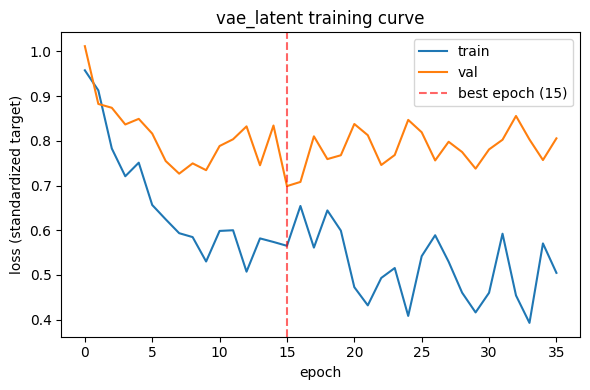

[vae_latent] TEST R2: 0.1586   Spearman rho: 0.4787


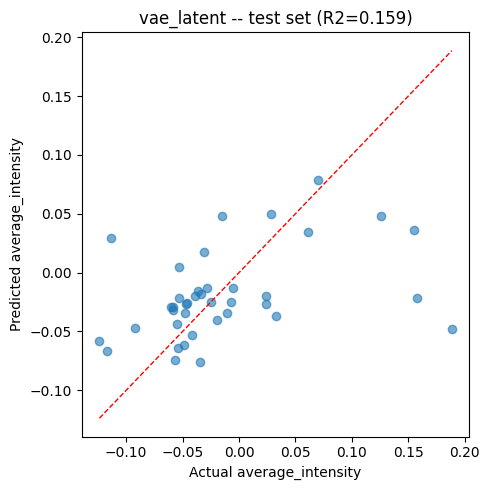

In [ ]:
vae_results = run_pipeline(X_vae_latent, y, train_idx, val_idx, test_idx, run_name='vae_latent')


PIPELINE: onehot_baseline  (input dim=10142)


[I 2026-07-17 00:34:52,756] A new study created in RDB with name: onehot_baseline_v3


[onehot_baseline] 0 trials already completed. Running 25 more.


[I 2026-07-17 00:34:56,482] Trial 0 finished with value: 0.8106458127498627 and parameters: {'hidden_dim': 16, 'dropout': 0.3993292420985183, 'learning_rate': 0.0002051338263087451, 'weight_decay': 4.207053950287933e-05, 'batch_size': 32}. Best is trial 0 with value: 0.8106458127498627.
[I 2026-07-17 00:35:00,286] Trial 1 finished with value: 0.9574314832687378 and parameters: {'hidden_dim': 16, 'dropout': 0.5849549260809972, 'learning_rate': 0.004622589001020831, 'weight_decay': 7.068974950624602e-05, 'batch_size': 32}. Best is trial 0 with value: 0.8106458127498627.
[I 2026-07-17 00:35:03,771] Trial 2 finished with value: 0.7678571343421936 and parameters: {'hidden_dim': 16, 'dropout': 0.24561457009902096, 'learning_rate': 0.0016738085788752138, 'weight_decay': 3.613894271216525e-05, 'batch_size': 32}. Best is trial 2 with value: 0.7678571343421936.
[I 2026-07-17 00:35:09,649] Trial 3 finished with value: 0.8620257377624512 and parameters: {'hidden_dim': 16, 'dropout': 0.357117219206

[onehot_baseline] Best mean CV val loss: 0.7591
[onehot_baseline] Best hyperparameters: {'hidden_dim': 32, 'dropout': 0.18005924856664068, 'learning_rate': 0.002388752873310766, 'weight_decay': 1.3934834101984693e-05, 'batch_size': 32}
[onehot_baseline] No checkpoint found -- starting fresh.
[onehot_baseline] Early stopping at epoch 38.


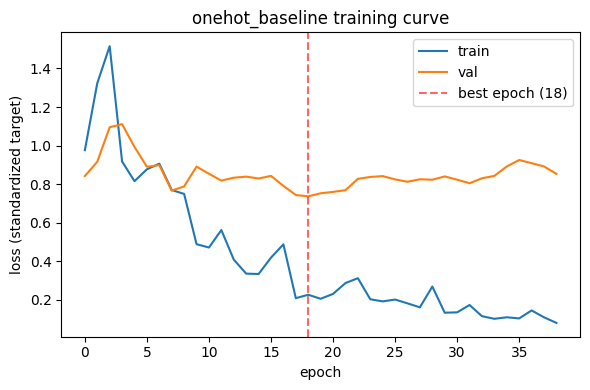

[onehot_baseline] TEST R2: 0.0864   Spearman rho: 0.3308


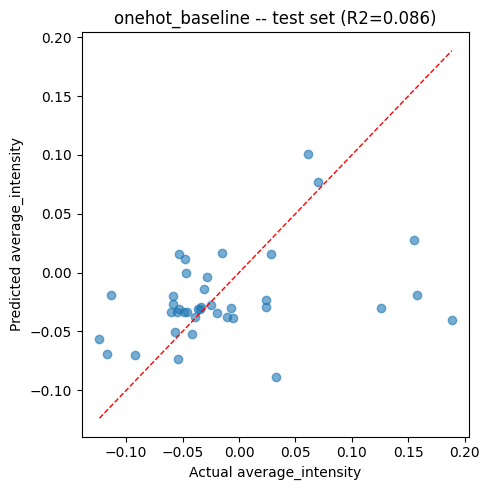

In [ ]:
onehot_results = run_pipeline(X_onehot, y, train_idx, val_idx, test_idx, run_name='onehot_baseline')

[I 2026-07-17 00:36:54,299] A new study created in RDB with name: raw_esm2_baseline_v3



PIPELINE: raw_esm2_baseline  (input dim=640)
[raw_esm2_baseline] 0 trials already completed. Running 25 more.


[I 2026-07-17 00:36:57,589] Trial 0 finished with value: 0.7582513749599457 and parameters: {'hidden_dim': 16, 'dropout': 0.3993292420985183, 'learning_rate': 0.0002051338263087451, 'weight_decay': 4.207053950287933e-05, 'batch_size': 32}. Best is trial 0 with value: 0.7582513749599457.
[I 2026-07-17 00:37:00,886] Trial 1 finished with value: 0.8275035262107849 and parameters: {'hidden_dim': 16, 'dropout': 0.5849549260809972, 'learning_rate': 0.004622589001020831, 'weight_decay': 7.068974950624602e-05, 'batch_size': 32}. Best is trial 0 with value: 0.7582513749599457.
[I 2026-07-17 00:37:04,190] Trial 2 finished with value: 0.7387209951877594 and parameters: {'hidden_dim': 16, 'dropout': 0.24561457009902096, 'learning_rate': 0.0016738085788752138, 'weight_decay': 3.613894271216525e-05, 'batch_size': 32}. Best is trial 2 with value: 0.7387209951877594.
[I 2026-07-17 00:37:09,848] Trial 3 finished with value: 0.6986453235149384 and parameters: {'hidden_dim': 16, 'dropout': 0.357117219206

[raw_esm2_baseline] Best mean CV val loss: 0.6518
[raw_esm2_baseline] Best hyperparameters: {'hidden_dim': 8, 'dropout': 0.10299859147790863, 'learning_rate': 0.008691089486124988, 'weight_decay': 0.017274255287824152, 'batch_size': 16}
[raw_esm2_baseline] No checkpoint found -- starting fresh.
[raw_esm2_baseline] Early stopping at epoch 28.


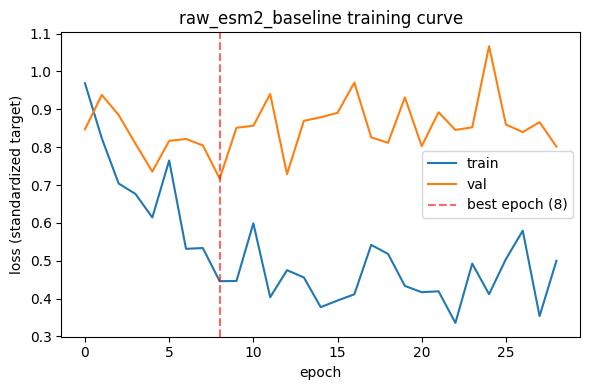

[raw_esm2_baseline] TEST R2: 0.2013   Spearman rho: 0.4500


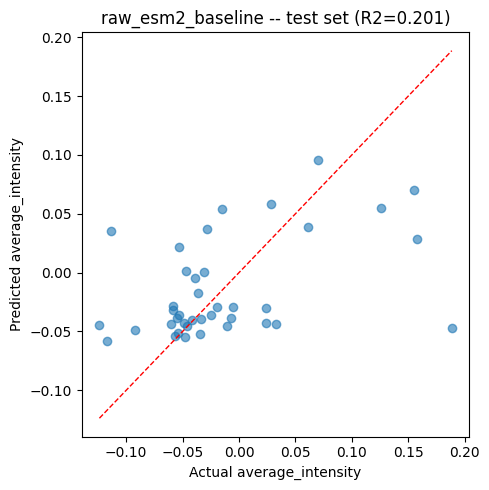

In [ ]:
raw_esm_results = run_pipeline(esm_embeddings, y, train_idx, val_idx, test_idx,
                                 run_name='raw_esm2_baseline')

## 10. Comparison

In [ ]:
comparison_df = pd.DataFrame([vae_results, onehot_results, raw_esm_results])[
    ['run_name', 'input_dim', 'r2', 'spearman', 'best_epoch', 'epochs_trained']]
comparison_df.to_csv(os.path.join(HEAD_DIR, f'comparison_{SEARCH_VERSION}.csv'), index=False)
comparison_df

,run_name,input_dim,r2,spearman,best_epoch,epochs_trained
0,vae_latent,36,0.158595,0.478745,15,36
1,onehot_baseline,10142,0.086411,0.330769,18,39
2,raw_esm2_baseline,640,0.201330,0.450000,8,29
